In [6]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as patches

## 1. Ángulo cenital de observación (satélite–Bogotá)

La corrección de paralaje no se implementa en este trabajo, pero antes de justificar esa decisión (Sección 3) es necesario cuantificar la magnitud del efecto. El primer paso es determinar el ángulo cenital de observación: el ángulo con el que GOES-East "ve" la Sabana de Bogotá desde su posición geoestacionaria, medido respecto a la vertical local en Bogotá.

Este cálculo sigue el método de aproximación esférica descrito por **Soler & Eisemann (1994)** para la determinación de ángulos de apuntamiento hacia satélites geoestacionarios. El procedimiento consta de tres pasos:
- (1) obtener el ángulo central entre Bogotá y el punto subsatelital mediante trigonometría esférica sobre la superficie terrestre;
- (2) aplicar la ley de cosenos para obtener la distancia línea-de-vista entre la estación y el satélite, y;
-  (3) aplicar la ley de senos sobre ese mismo triángulo para resolver el ángulo cenital de observación.

In [34]:
# --- Geometría de entrada ---
lat_bogota = 4.6      # grados N
lon_bogota = -74.1    # grados (negativo = Oeste)

lat_subsat = 0.0      # GOES-East, punto subsatelital
lon_subsat = -75.2

R_tierra = 6371.0         # km, radio medio terrestre (Soler & Eisemann, 1994, usan R = 6371 km)
altura_orbital = 35786.0  # km, altura del satélite geoestacionario sobre la superficie
Rs = R_tierra + altura_orbital  # distancia del satélite al centro de la Tierra

# --- Paso 1: ángulo central (distancia angular) entre Bogotá y el punto subsatelital ---
lat1, lon1 = np.radians(lat_bogota), np.radians(lon_bogota)
lat2, lon2 = np.radians(lat_subsat), np.radians(lon_subsat)

cos_lambda = np.sin(lat1) * np.sin(lat2) + np.cos(lat1) * np.cos(lat2) * np.cos(lon1 - lon2)
lam = np.arccos(cos_lambda)
lam_deg = np.degrees(lam)

print(f"Ángulo central (Tierra) Bogotá–subsatelital: {lam_deg:.4f}°")

# --- Paso 2: distancia línea-de-vista superficie–satélite (ley de cosenos) ---
# Ecuación (2) de Soler & Eisemann (1994): d = r[1 + (R/r)² - 2(R/r)cos γ]^(1/2)
d = np.sqrt(R_tierra**2 + Rs**2 - 2 * R_tierra * Rs * np.cos(lam))

print(f"Distancia superficie–satélite (d): {d:,.1f} km")

# --- Paso 3: ángulo cenital de observación desde Bogotá hacia el satélite ---
# Ecuaciones (3)-(4) de Soler & Eisemann (1994): r/sin(z') = d/sin(γ)  →  z' = sin⁻¹[(r/d)·sin(γ)]
sin_theta = (Rs / d) * np.sin(lam)
theta = np.arcsin(sin_theta)
theta_deg = np.degrees(theta)

print(f"Ángulo cenital de observación (θ): {theta_deg:.3f}°")

Ángulo central (Tierra) Bogotá–subsatelital: 4.7294°
Distancia superficie–satélite (d): 35,811.5 km
Ángulo cenital de observación (θ): 5.570°


**Validez de la aproximación esférica**. Soler & Eisemann (1994) comparan este método esférico contra una formulación elipsoidal más rigurosa, y reportan el error introducido por la simplificación en función de la latitud de la estación. Para una estación a 5° de latitud — la más cercana en su tabla a la latitud de Bogotá (4.6°N) — _el error en el ángulo vertical entre ambos métodos es de apenas **0.0046°**_, muy por debajo del error máximo del método (0.023°, en torno a los 43° de latitud). Propagado a desplazamiento en superficie, este error equivale a un orden de magnitud de decenas de metros — despreciable frente al desplazamiento de paralaje calculado en la Sección 2 (~1.3 km) y frente a la resolución de píxel de la banda 13 (2 km). Esto respalda el uso de la aproximación esférica en este trabajo, sin necesidad de una formulación elipsoidal más compleja.

**Referencia**: Soler, T., & Eisemann, D. W. (1994). Determination of look angles to geostationary communication satellites. Journal of Surveying Engineering (ASCE), 120(3), 115–127. https://doi.org/10.1061/(ASCE)0733-9453(1994)120:3(115)

## 2. Desplazamiento de paralaje en superficie

Con el ángulo cenital de observación ya calculado y verificado (`θ = 5.570°`, Sección 1), el siguiente paso es determinar el desplazamiento horizontal que produce el paralaje para una nube de altura `h`, mediante la aproximación estándar:

$Δ = h · tan(θ)$

**Rango de altura de tope de nube**. Se adopta un rango de **12–14 km**, anclado en las observaciones satelitales de Chae & Sherwood (2010) sobre convección profunda tropical en el Pacífico Occidental cálido: el pico característico de nubes ópticamente gruesas (correspondientes a núcleos convectivos, no a cirros residuales) se ubica en ~14 km, con simulaciones del modelo WRF que producen alturas máximas de nube (MCH) entre 13 y 15 km.

Es necesario señalar una limitación de esta referencia: Chae & Sherwood (2010) estudian convección **oceánica**, explícitamente elegida por sus autores por tratarse de un entorno con menor variabilidad topográfica — el opuesto del régimen que domina la Sabana de Bogotá, donde la convección es diurna, continental y fuertemente modulada por el forzamiento térmico de la topografía circundante (Casallas-García et al., 2023). Una revisión bibliográfica dirigida específicamente a literatura sobre altura de tope de nube en sistemas convectivos continentales y de terreno montañoso (incluyendo estudios sobre los Andes y el Valle del Magdalena, geográficamente adyacente a Bogotá) no arrojó un valor cuantitativo directamente aplicable al caso de la Sabana. Esta ausencia se documenta como una limitación explícita del cálculo, más que ocultarse detrás de una cita que no representa con precisión el fenómeno de interés. Dado que la convección continental tiende, en términos generales, a producir topes de nube iguales o más altos que la convección oceánica de referencia, el rango aquí adoptado puede interpretarse como un límite conservador antes que una sobreestimación.

In [35]:
# --- Desplazamiento de paralaje ---
alturas_nube = np.array([12, 13, 14])  # km, anclado a Chae & Sherwood (2010):
                                          # pico de convección profunda tropical (oceánica) en ~13-14 km

theta_rad = np.radians(theta_deg)  # reutilizando el ángulo calculado en la Sección 1
desplazamientos = alturas_nube * np.tan(theta_rad)

for h, d_parallax in zip(alturas_nube, desplazamientos):
    print(f"Altura de nube: {h} km  →  desplazamiento de paralaje: {d_parallax:.3f} km")

print(f"\nRango de desplazamiento (12–14 km): {desplazamientos.min():.3f} – {desplazamientos.max():.3f} km")

Altura de nube: 12 km  →  desplazamiento de paralaje: 1.170 km
Altura de nube: 13 km  →  desplazamiento de paralaje: 1.268 km
Altura de nube: 14 km  →  desplazamiento de paralaje: 1.365 km

Rango de desplazamiento (12–14 km): 1.170 – 1.365 km


**Referencia**: Chae, J.-H., & Sherwood, S. C. (2010). Insights into cloud-top height and dynamics from the seasonal cycle of cloud-top heights observed by MISR in the West Pacific region. Journal of the Atmospheric Sciences, 67(1), 248–261. https://doi.org/10.1175/2009JAS3099.1

## 3. Verificar si la resolución de píxel se degrada al ángulo de observación

La resolución nominal de 2 km de la banda 13 del ABI corresponde a la observación en nadir. Fuera del nadir, el píxel proyectado sobre la superficie terrestre se degrada — su tamaño efectivo crece con el ángulo de observación, un efecto confirmado específicamente para el sensor ABI por **Schmit et al. (2017)**, quienes señalan que una banda con resolución nominal de 1 km en nadir alcanza aproximadamente 2 km sobre la extensión del dominio CONUS observado desde GOES-East (ángulos de varias decenas de grados). 

Geométricamente, esta degradación sigue la relación de proyección estándar $resolución_efectiva = resolución_nominal / cos(θ)$, aplicada aquí al ángulo cenital de observación ya calculado para Bogotá (θ = 5.570°, Sección 1).

**nadir**: punto directamente debajo del satélite — la línea recta que va del satélite hacia el centro de la Tierra, y el punto donde esa línea toca la superficie.
**cenit**: opuesto al nadir, es el punto donde está el satélite, situado exactamente sobre la cabeza del observador (a 90 grados de altura)

In [36]:
resolucion_nominal = 2.0  # km, banda 13 en nadir (Schmit et al., 2017)
resolucion_efectiva = resolucion_nominal / np.cos(theta_rad)

print(f"Resolución nominal (nadir): {resolucion_nominal:.3f} km")
print(f"Resolución efectiva a θ={theta_deg:.3f}°: {resolucion_efectiva:.3f} km")
print(f"Degradación: {(resolucion_efectiva - resolucion_nominal):.4f} km ({(resolucion_efectiva/resolucion_nominal - 1)*100:.2f}%)")

print(f"\nDesplazamiento de paralaje (12-14km): {desplazamientos.min():.3f} - {desplazamientos.max():.3f} km")
print(f"Resolución efectiva de píxel: {resolucion_efectiva:.3f} km")
print(f"¿Desplazamiento < resolución efectiva?: {desplazamientos.max() < resolucion_efectiva}")

Resolución nominal (nadir): 2.000 km
Resolución efectiva a θ=5.570°: 2.009 km
Degradación: 0.0095 km (0.47%)

Desplazamiento de paralaje (12-14km): 1.170 - 1.365 km
Resolución efectiva de píxel: 2.009 km
¿Desplazamiento < resolución efectiva?: True


**Referencia**: Schmit, T. J., Griffith, P., Gunshor, M. M., Daniels, J. M., Goodman, S. J., & Lebair, W. J. (2017). A closer look at the ABI on the GOES-R series. Bulletin of the American Meteorological Society, 98(4), 681–698. https://doi.org/10.1175/BAMS-D-15-00230.1

## 4. Figura de la geometría

Ahora la figura ilustrativa para la tesis. Va a ser un esquema simple (no a escala geográfica real, sino conceptual) mostrando: el satélite, el ángulo de observación, la nube con su tope, la posición real vs. la posición aparente en superficie, y el desplazamiento marcado.

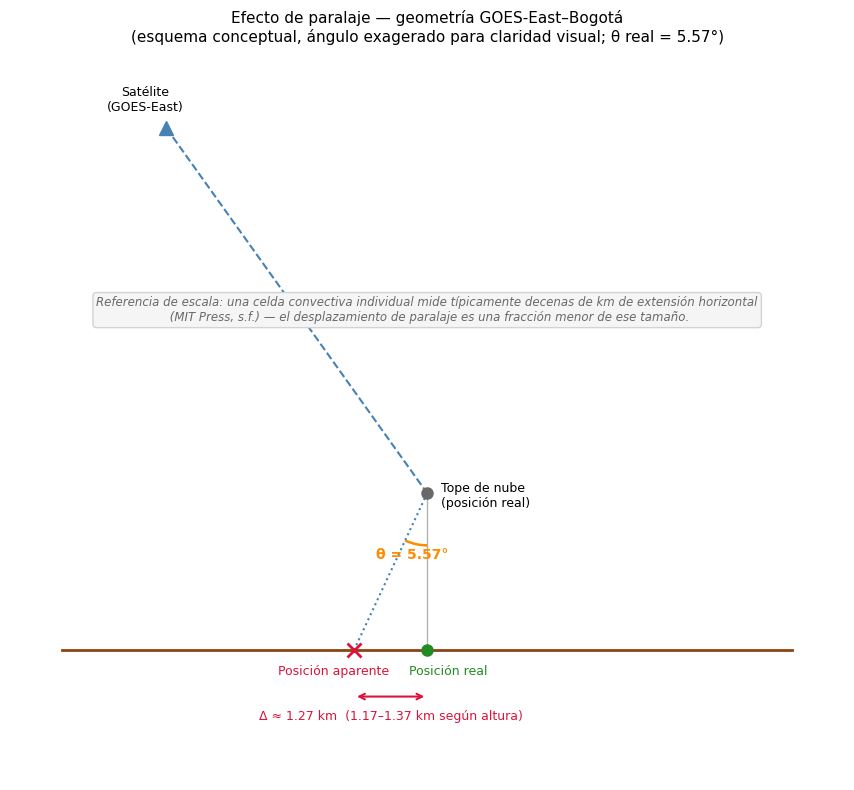

Figura guardada: img-esquema_paralaje.png


In [37]:
fig, ax = plt.subplots(figsize=(10, 8))

sat_x, sat_y = 0, 10
cloud_top_x, cloud_top_y = 5, 3
theta_visual = 25

displaced_x = cloud_top_x - cloud_top_y * np.tan(np.radians(theta_visual))

# Superficie
ax.plot([-2, 12], [0, 0], color='saddlebrown', linewidth=2)

# Vertical de referencia (nadir)
ax.plot([cloud_top_x, cloud_top_x], [cloud_top_y, 0], '-', color='gray', linewidth=1, alpha=0.6)

# Línea de visión satélite → tope de nube → posición aparente
ax.plot([sat_x, cloud_top_x], [sat_y, cloud_top_y], '--', color='steelblue', linewidth=1.5)
ax.plot([cloud_top_x, displaced_x], [cloud_top_y, 0], ':', color='steelblue', linewidth=1.5)

ax.plot(sat_x, sat_y, '^', color='steelblue', markersize=10)
ax.annotate('Satélite\n(GOES-East)', (sat_x, sat_y), textcoords="offset points",
            xytext=(-15, 12), fontsize=9, ha='center')

ax.plot(cloud_top_x, cloud_top_y, 'o', color='dimgray', markersize=8)
ax.annotate('Tope de nube\n(posición real)', (cloud_top_x, cloud_top_y),
            textcoords="offset points", xytext=(10, -10), fontsize=9)

# Marcadores en superficie
ax.plot(displaced_x, 0, 'x', color='crimson', markersize=10, markeredgewidth=2)
ax.plot(cloud_top_x, 0, 'o', color='forestgreen', markersize=8)

# Etiquetas de los puntos: directamente debajo de cada marcador, cortas, sin chocar con el resto
ax.annotate('Posición aparente', (displaced_x, 0), textcoords="offset points",
            xytext=(-15, -18), fontsize=9, color='crimson', ha='center')
ax.annotate('Posición real', (cloud_top_x, 0), textcoords="offset points",
            xytext=(15, -18), fontsize=9, color='forestgreen', ha='center')

# Arco del ángulo θ
arc_radius = 1.0
theta_arc = patches.Arc((cloud_top_x, cloud_top_y), arc_radius*2, arc_radius*2,
                         angle=0, theta1=270-theta_visual, theta2=270,
                         color='darkorange', linewidth=1.8)
ax.add_patch(theta_arc)
label_angle = np.radians(270 - theta_visual/2)
ax.annotate(f'θ = {theta_deg:.2f}°',
            (cloud_top_x + (arc_radius+0.3)*np.cos(label_angle), cloud_top_y + (arc_radius+0.3)*np.sin(label_angle)),
            fontsize=10, color='darkorange', fontweight='bold', ha='center')

# Flecha de desplazamiento y su valor, en una fila propia más abajo (sin chocar con las etiquetas de punto)
ax.annotate('', xy=(cloud_top_x, -0.9), xytext=(displaced_x, -0.9),
            arrowprops=dict(arrowstyle='<->', color='crimson', lw=1.5))
ax.annotate(f'Δ ≈ {desplazamientos.mean():.2f} km  (1.17–1.37 km según altura)',
            ((cloud_top_x+displaced_x)/2, -1.35), ha='center', fontsize=9, color='crimson')

# Referencia de escala
ax.annotate('Referencia de escala: una celda convectiva individual mide típicamente decenas de km de extensión horizontal\n'
            ' (MIT Press, s.f.) — el desplazamiento de paralaje es una fracción menor de ese tamaño.',
            (5, 6.3), ha='center', fontsize=8.5, style='italic', color='dimgray',
            bbox=dict(boxstyle='round', facecolor='whitesmoke', edgecolor='lightgray'))

ax.set_xlim(-3, 13)
ax.set_ylim(-2.5, 11.5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(f'Efecto de paralaje — geometría GOES-East–Bogotá\n'
             f'(esquema conceptual, ángulo exagerado para claridad visual; θ real = {theta_deg:.2f}°)',
             fontsize=11)

plt.tight_layout()
plt.savefig('img-esquema_paralaje.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figura guardada: img-esquema_paralaje.png")